# Scam Website Detection ML - Visualization Dashboard

This notebook creates presentation-ready visualizations for the scam website detection project.

It uses the current project artifacts:

- `dataset/reference_training_dataset_5000_clean.csv`
- `dataset/real_site_prediction_results.csv`
- `pkl_models/training_report.json`
- `pkl_models/best_scam_detector.pkl`
- `pkl_models/model_features.pkl`

The goal is to show the solution clearly: dataset balance, feature behavior, model comparison, final performance, and real-world testing.

## 1. Imports and Styling

In [1]:
from pathlib import Path
import json
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["axes.titlesize"] = 16

PROJECT_ROOT = Path.cwd()
DATASET_PATH = PROJECT_ROOT / "dataset" / "reference_training_dataset_5000_clean.csv"
REAL_RESULTS_PATH = PROJECT_ROOT / "dataset" / "real_site_prediction_results.csv"
REPORT_PATH = PROJECT_ROOT / "pkl_models" / "training_report.json"
MODEL_PATH = PROJECT_ROOT / "pkl_models" / "best_scam_detector.pkl"
FEATURES_PATH = PROJECT_ROOT / "pkl_models" / "model_features.pkl"

PALETTE = {"LEGIT": "#2A9D8F", "SCAM": "#E76F51"}
MODEL_COLOR = "#457B9D"
ACCENT_COLOR = "#F4A261"

print("Notebook paths configured.")

Notebook paths configured.


## 2. Load Project Artifacts

In [2]:
df = pd.read_csv(DATASET_PATH)
real_df = pd.read_csv(REAL_RESULTS_PATH)

with REPORT_PATH.open("r", encoding="utf-8") as f:
    report = json.load(f)

feature_columns = joblib.load(FEATURES_PATH)
model = joblib.load(MODEL_PATH)

df["label_name"] = df["label"].map({0: "LEGIT", 1: "SCAM"})
real_df["expected_name"] = real_df["expected_label"].map({0: "LEGIT", 1: "SCAM"})
real_df["predicted_name"] = real_df["predicted_label"].map({0: "LEGIT", 1: "SCAM"})

summary = pd.DataFrame(
    {
        "Metric": [
            "Training rows",
            "Clean dataset columns",
            "Model features",
            "Best model",
            "Probability calibrated",
            "Real-site correct",
        ],
        "Value": [
            len(df),
            df.shape[1] - 1,
            len(feature_columns),
            report["best_model"],
            report["calibrated"],
            f"{int(real_df['correct'].sum())}/{len(real_df)}",
        ],
    }
)

summary

,Metric,Value
0,Training rows,5000
1,Clean dataset columns,36
2,Model features,35
3,Best model,extra_trees
4,Probability calibrated,True
5,Real-site correct,43/43


## 3. Dataset Balance

A balanced dataset is important because the model should learn both legitimate and scam patterns instead of simply favoring the majority class.

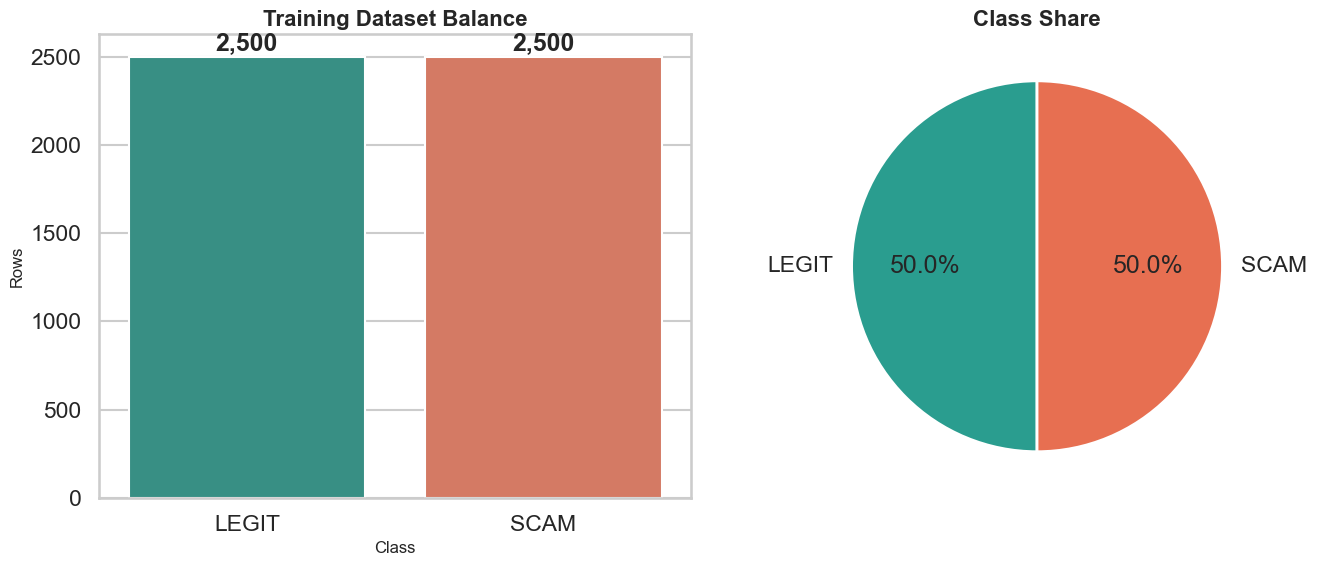

In [3]:
label_counts = df["label_name"].value_counts().reindex(["LEGIT", "SCAM"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.barplot(x=label_counts.index, y=label_counts.values, palette=PALETTE, ax=axes[0])
axes[0].set_title("Training Dataset Balance")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Rows")
for index, value in enumerate(label_counts.values):
    axes[0].text(index, value + 35, f"{value:,}", ha="center", fontweight="bold")

axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=[PALETTE["LEGIT"], PALETTE["SCAM"]],
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Class Share")

plt.tight_layout()
plt.show()

## 4. Feature Groups

The model combines URL structure signals, hosting/domain-style signals, and page-content signals.

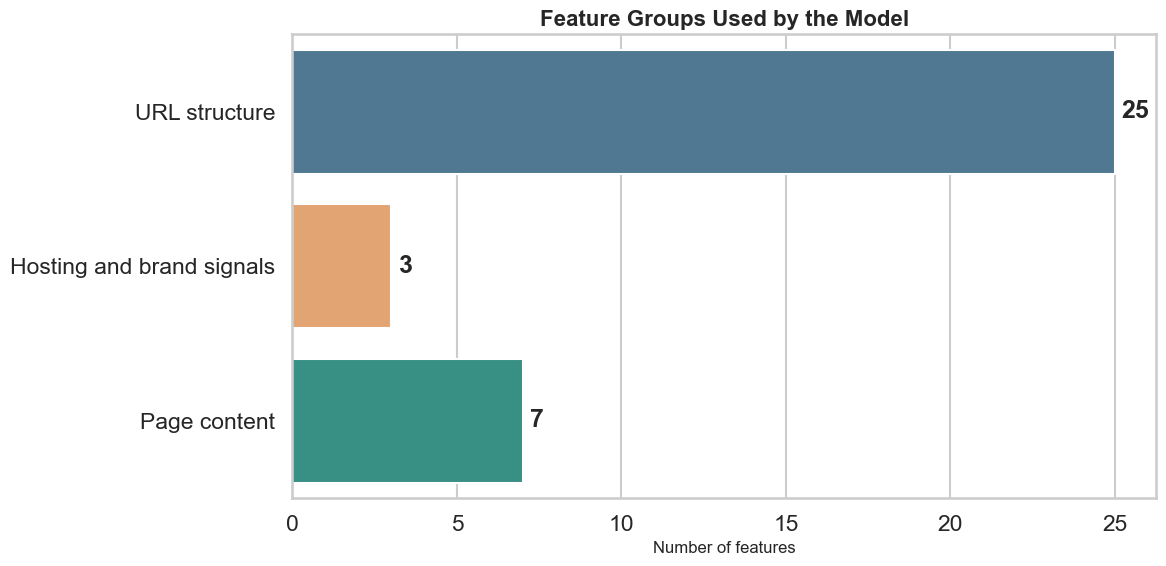

,Group,Feature count
0,URL structure,25
1,Hosting and brand signals,3
2,Page content,7


In [4]:
url_features = [
    "url_length", "num_dots", "num_hyphen", "num_slashes", "https", "subdomains",
    "has_at_symbol", "has_double_slash", "has_ip", "num_underscores", "num_percent",
    "num_digits", "num_query_params", "has_query", "path_depth", "suspicious_tld",
    "brand_in_url", "is_shortened", "suspicious_word_count", "url_entropy",
    "hostname_length", "digit_letter_ratio", "num_special_chars", "tld_in_path",
    "longest_digit_run",
]
hosting_features = ["uses_free_hosting", "brand_on_free_hosting", "brand_domain_mismatch"]
content_features = [
    "text_length", "token_count", "scam_keyword_count", "scam_keyword_density",
    "exclamation_count", "caps_ratio", "avg_word_length",
]

feature_groups = pd.DataFrame(
    {
        "Group": ["URL structure", "Hosting and brand signals", "Page content"],
        "Feature count": [len(url_features), len(hosting_features), len(content_features)],
    }
)

ax = sns.barplot(data=feature_groups, x="Feature count", y="Group", palette=["#457B9D", "#F4A261", "#2A9D8F"])
ax.set_title("Feature Groups Used by the Model")
ax.set_xlabel("Number of features")
ax.set_ylabel("")
for container in ax.containers:
    ax.bar_label(container, padding=5, fontweight="bold")
plt.tight_layout()
plt.show()

feature_groups

## 5. Legit vs Scam Feature Comparison

These charts show how selected features differ between legitimate and scam URLs.

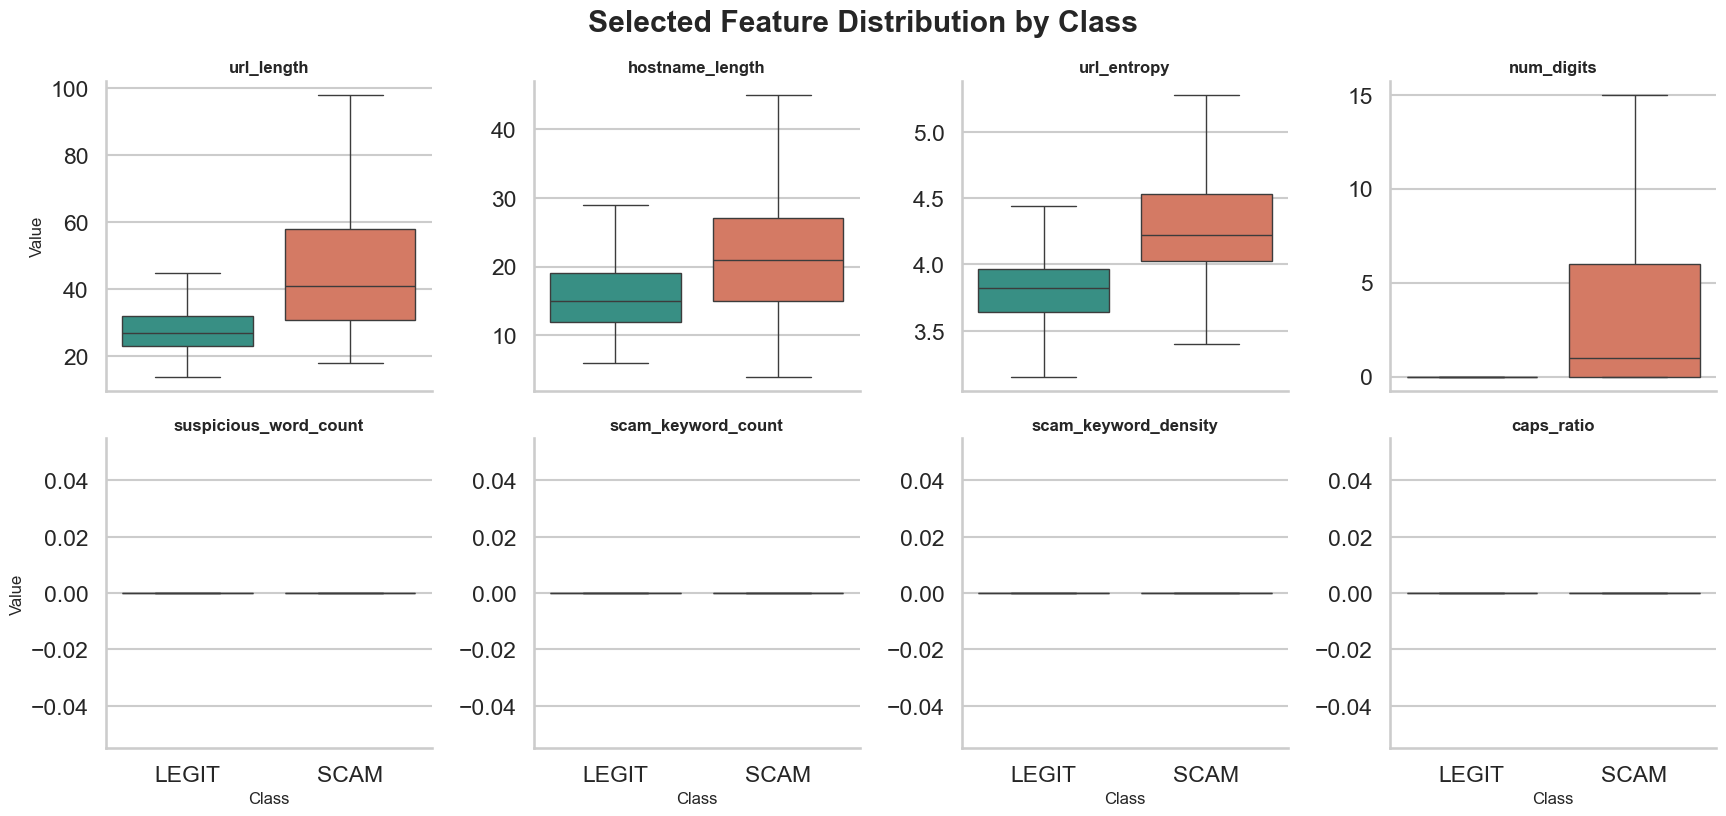

In [5]:
selected_features = [
    "url_length",
    "hostname_length",
    "url_entropy",
    "num_digits",
    "suspicious_word_count",
    "scam_keyword_count",
    "scam_keyword_density",
    "caps_ratio",
]

available_features = [feature for feature in selected_features if feature in df.columns]
plot_df = df[["label_name", *available_features]].melt(
    id_vars="label_name",
    var_name="Feature",
    value_name="Value",
)

g = sns.catplot(
    data=plot_df,
    x="label_name",
    y="Value",
    col="Feature",
    kind="box",
    col_wrap=4,
    sharey=False,
    palette=PALETTE,
    height=4,
    aspect=1.1,
    showfliers=False,
)
g.set_axis_labels("Class", "Value")
g.set_titles("{col_name}")
g.fig.suptitle("Selected Feature Distribution by Class", y=1.03, fontweight="bold")
plt.show()

## 6. Feature Correlation Heatmap

This heatmap shows relationships among the most variable features. It helps explain which signals move together.

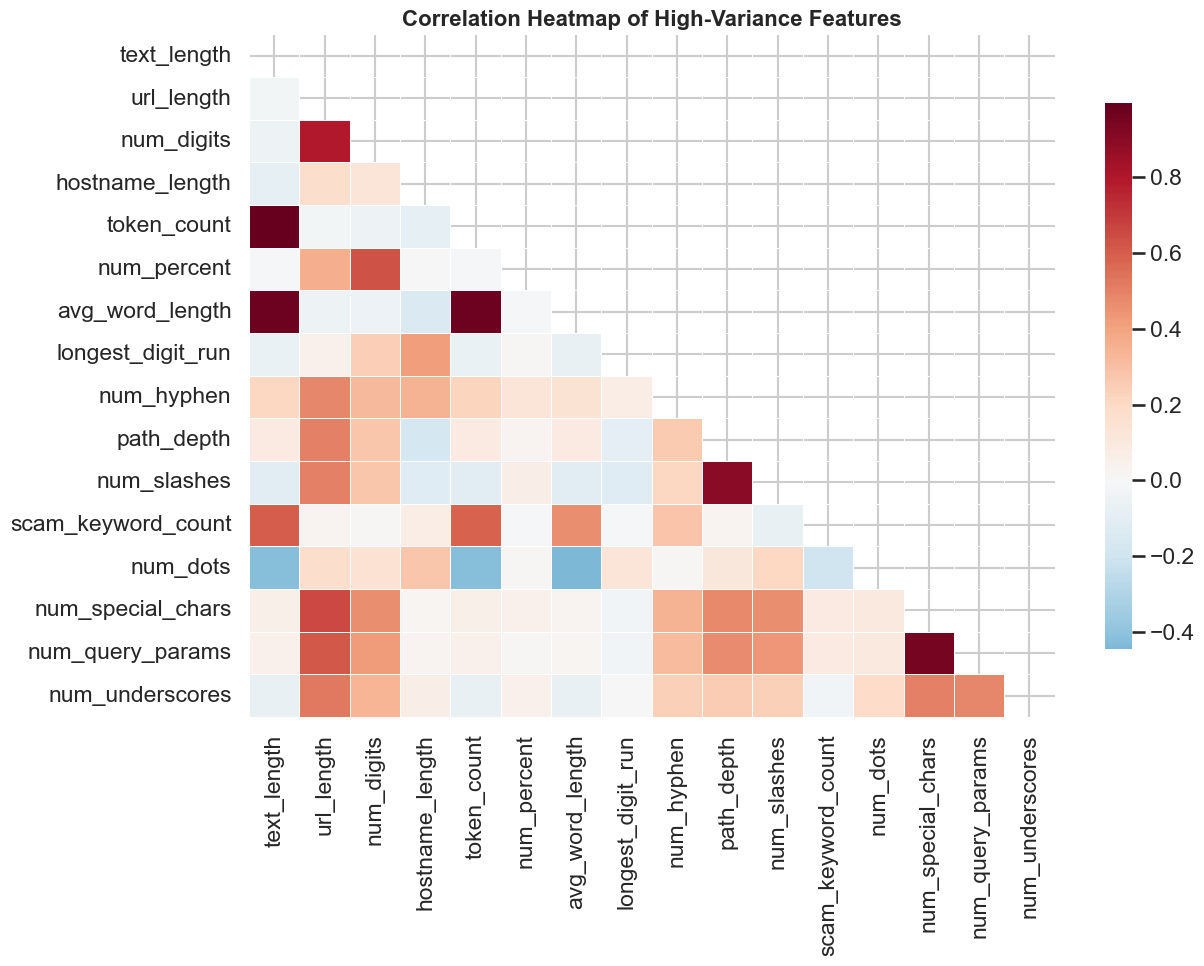

In [6]:
numeric_features = [column for column in feature_columns if column in df.columns]
variance = df[numeric_features].var(numeric_only=True).sort_values(ascending=False)
top_corr_features = variance.head(16).index.tolist()

corr = df[top_corr_features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(13, 10))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",
    center=0,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlation Heatmap of High-Variance Features")
plt.tight_layout()
plt.show()

## 7. Model Comparison

The training process compared multiple models using cross-validation. Extra Trees achieved the best F1 score.

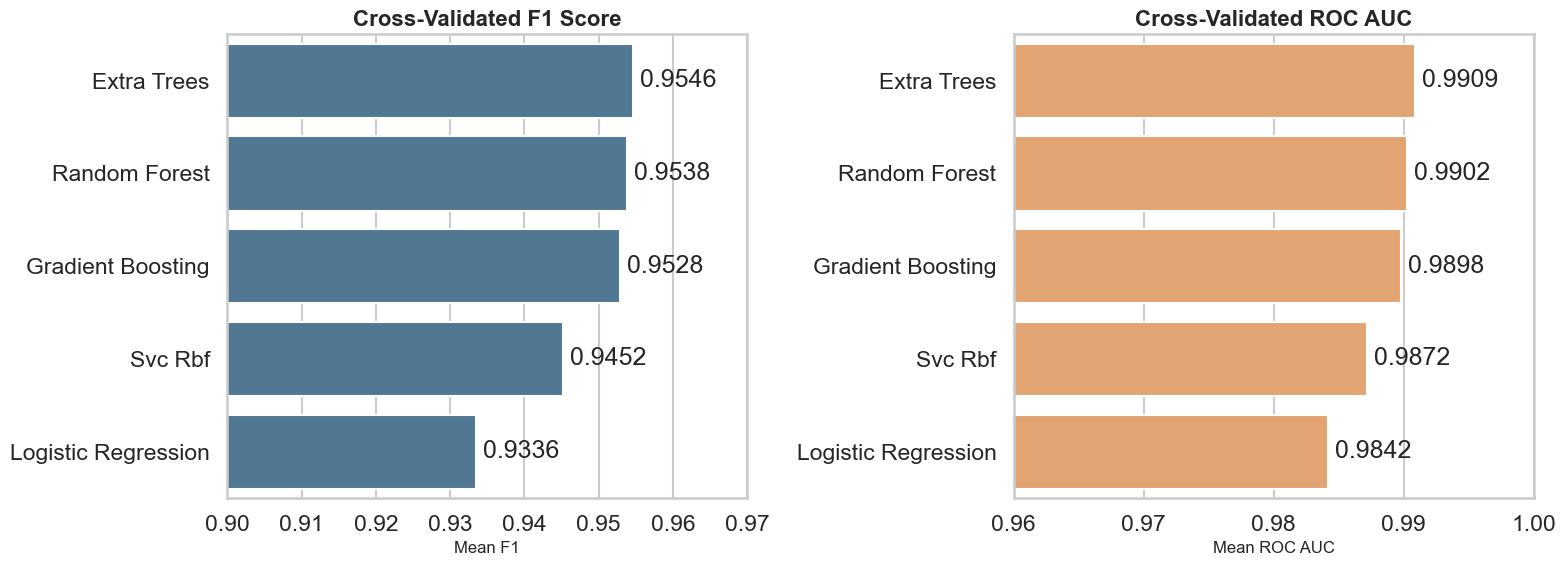

,display_model,accuracy_mean,precision_mean,recall_mean,f1_mean,roc_auc_mean
0,Extra Trees,0.95500,0.960969,0.9485,0.954638,0.990866
1,Random Forest,0.95400,0.957736,0.9500,0.953794,0.990224
2,Gradient Boosting,0.95325,0.960499,0.9455,0.952835,0.989811
3,Svc Rbf,0.94600,0.958888,0.9320,0.945225,0.987158
4,Logistic Regression,0.93425,0.943331,0.9240,0.933551,0.984206


In [7]:
cv_df = pd.DataFrame(report["cv_results"])
cv_df["display_model"] = cv_df["model"].str.replace("_", " ").str.title()
cv_df = cv_df.sort_values("f1_mean", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=cv_df, x="f1_mean", y="display_model", color=MODEL_COLOR, ax=axes[0])
axes[0].set_title("Cross-Validated F1 Score")
axes[0].set_xlabel("Mean F1")
axes[0].set_ylabel("")
axes[0].set_xlim(0.90, 0.97)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.4f", padding=5)

sns.barplot(data=cv_df, x="roc_auc_mean", y="display_model", color=ACCENT_COLOR, ax=axes[1])
axes[1].set_title("Cross-Validated ROC AUC")
axes[1].set_xlabel("Mean ROC AUC")
axes[1].set_ylabel("")
axes[1].set_xlim(0.96, 1.00)
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.4f", padding=5)

plt.tight_layout()
plt.show()

cv_df[["display_model", "accuracy_mean", "precision_mean", "recall_mean", "f1_mean", "roc_auc_mean"]]

## 8. Holdout Test Performance

The holdout metrics measure performance on data not used for fitting the final model.

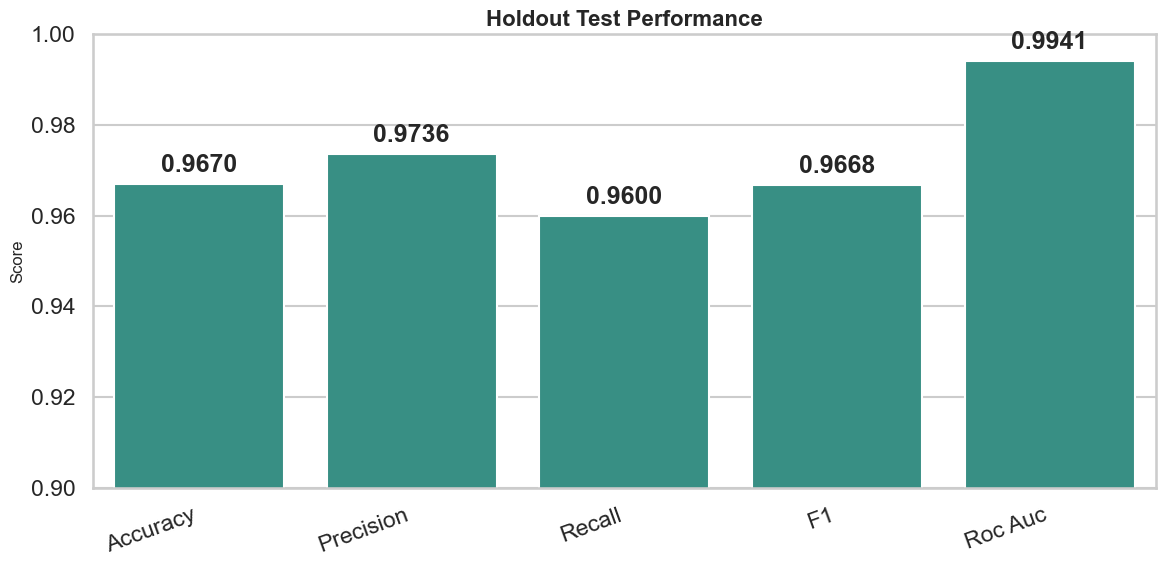

,Metric,Score
0,Accuracy,0.967000
1,Precision,0.973631
2,Recall,0.960000
3,F1,0.966767
4,Roc Auc,0.994098


In [8]:
holdout_df = pd.DataFrame(
    {
        "Metric": [metric.replace("_", " ").title() for metric in report["holdout_metrics"].keys()],
        "Score": list(report["holdout_metrics"].values()),
    }
)

ax = sns.barplot(data=holdout_df, x="Metric", y="Score", color="#2A9D8F")
ax.set_title("Holdout Test Performance")
ax.set_ylim(0.90, 1.00)
ax.set_xlabel("")
ax.set_ylabel("Score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.4f", padding=5, fontweight="bold")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

holdout_df

## 9. Feature Importance

Tree-based models provide feature importance scores. For the calibrated model, this cell extracts importance from the underlying Extra Trees estimators.

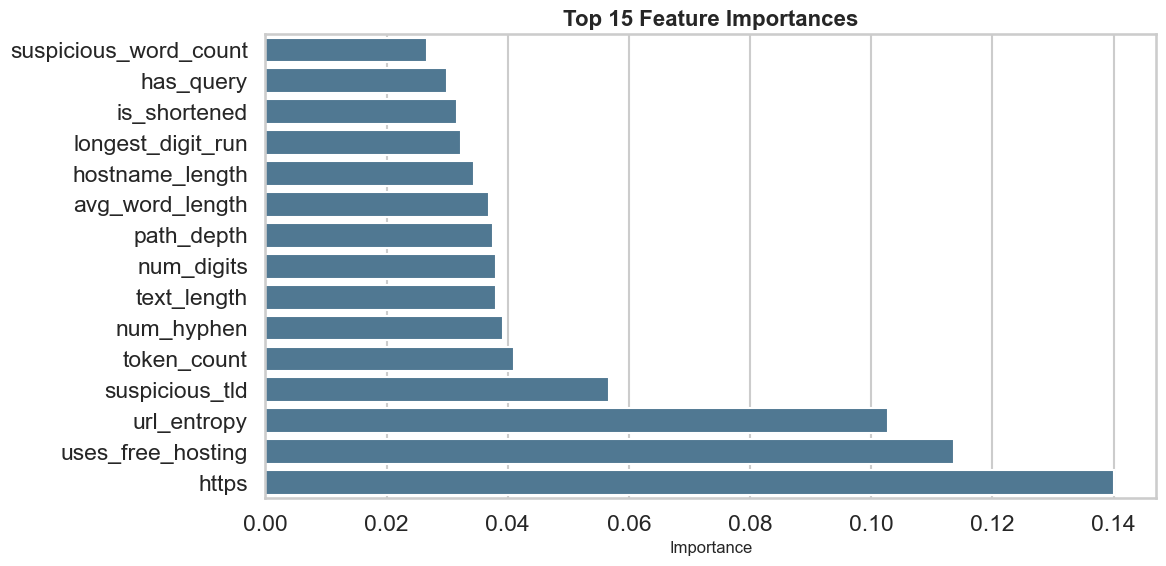

,Feature,Importance
4,https,0.140009
25,uses_free_hosting,0.113648
19,url_entropy,0.102835
15,suspicious_tld,0.056758
29,token_count,0.041066
2,num_hyphen,0.039264
28,text_length,0.038129
11,num_digits,0.038035
14,path_depth,0.037650
34,avg_word_length,0.036940


In [9]:
def extract_feature_importance(saved_model, feature_names):
    importances = []

    # CalibratedClassifierCV stores one fitted estimator per calibration split.
    if hasattr(saved_model, "calibrated_classifiers_"):
        for calibrated in saved_model.calibrated_classifiers_:
            estimator = getattr(calibrated, "estimator", None) or getattr(calibrated, "base_estimator", None)
            if hasattr(estimator, "named_steps"):
                tree_model = estimator.named_steps.get("model")
                if hasattr(tree_model, "feature_importances_"):
                    importances.append(tree_model.feature_importances_)

    # Non-calibrated pipeline fallback.
    if not importances and hasattr(saved_model, "named_steps"):
        tree_model = saved_model.named_steps.get("model")
        if hasattr(tree_model, "feature_importances_"):
            importances.append(tree_model.feature_importances_)

    if not importances:
        return pd.DataFrame(columns=["Feature", "Importance"])

    mean_importance = np.mean(np.vstack(importances), axis=0)
    return pd.DataFrame({"Feature": feature_names, "Importance": mean_importance}).sort_values(
        "Importance", ascending=False
    )

importance_df = extract_feature_importance(model, feature_columns)
top_importance = importance_df.head(15).sort_values("Importance", ascending=True)

if top_importance.empty:
    print("Feature importance is not available for this saved model type.")
else:
    ax = sns.barplot(data=top_importance, x="Importance", y="Feature", color="#457B9D")
    ax.set_title("Top 15 Feature Importances")
    ax.set_xlabel("Importance")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

importance_df.head(20)

## 10. Real-Site Evaluation

This section visualizes the saved evaluation on real legitimate sites and fresh scam/phishing URLs.

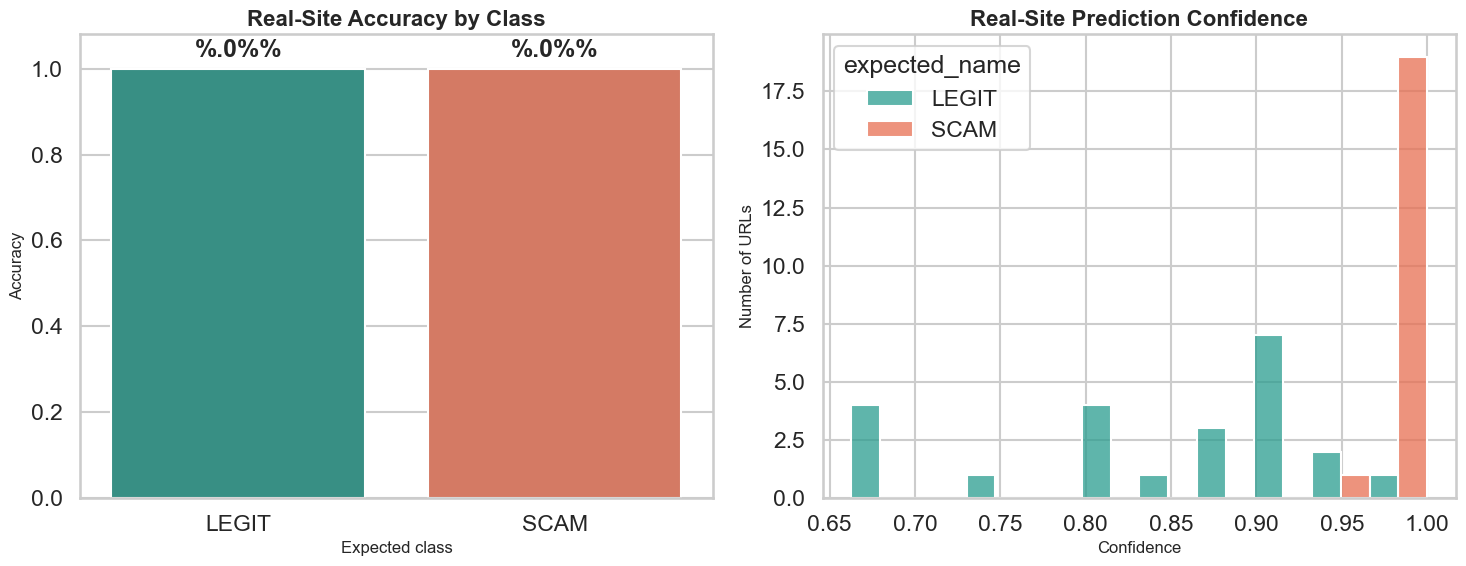

,expected_name,total,correct,avg_confidence,accuracy
0,LEGIT,23,23,0.847194,1.0
1,SCAM,20,20,0.998296,1.0


In [10]:
real_summary = real_df.groupby("expected_name").agg(
    total=("correct", "count"),
    correct=("correct", "sum"),
    avg_confidence=("confidence", "mean"),
).reset_index()
real_summary["accuracy"] = real_summary["correct"] / real_summary["total"]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=real_summary, x="expected_name", y="accuracy", palette=PALETTE, ax=axes[0])
axes[0].set_title("Real-Site Accuracy by Class")
axes[0].set_xlabel("Expected class")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0, 1.08)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%.0%%", padding=5, fontweight="bold")

sns.histplot(
    data=real_df,
    x="confidence",
    hue="expected_name",
    bins=10,
    multiple="dodge",
    palette=PALETTE,
    ax=axes[1],
)
axes[1].set_title("Real-Site Prediction Confidence")
axes[1].set_xlabel("Confidence")
axes[1].set_ylabel("Number of URLs")

plt.tight_layout()
plt.show()

real_summary

## 11. Real-Site Confusion Matrix

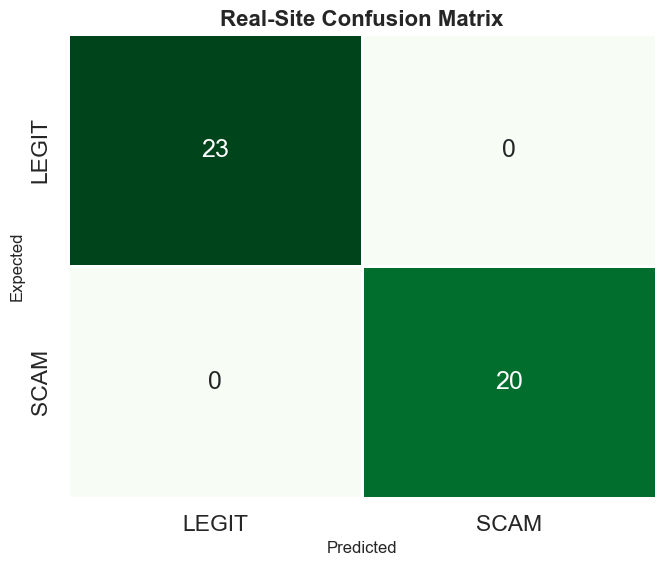

Predicted,LEGIT,SCAM
Expected,,
LEGIT,23,0
SCAM,0,20


In [11]:
confusion = pd.crosstab(
    real_df["expected_name"],
    real_df["predicted_name"],
    rownames=["Expected"],
    colnames=["Predicted"],
).reindex(index=["LEGIT", "SCAM"], columns=["LEGIT", "SCAM"], fill_value=0)

plt.figure(figsize=(7, 6))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Greens", cbar=False, linewidths=1, linecolor="white")
plt.title("Real-Site Confusion Matrix")
plt.tight_layout()
plt.show()

confusion

## 12. Most Confident Real-Site Predictions

Use this table during presentation to show concrete examples of the model's predictions.

In [12]:
display_columns = ["url", "expected_name", "predicted_name", "confidence", "scam_probability", "correct"]
examples = real_df[display_columns].copy()
examples["confidence"] = (examples["confidence"] * 100).round(2)
examples["scam_probability"] = (examples["scam_probability"] * 100).round(2)
examples = examples.sort_values(["correct", "confidence"], ascending=[True, False])
examples.head(12)

,url,expected_name,predicted_name,confidence,scam_probability,correct
19,https://www.kaggle.com,LEGIT,LEGIT,100.0,0.0,1
23,https://roblox.com.bn/games/74538164085210/swo...,SCAM,SCAM,100.0,100.0,1
24,http://bafkreia4gwi65juhfno264zzcmomalln4ipqo2...,SCAM,SCAM,100.0,100.0,1
25,http://bafkreiezyyuwkx6lx4ibhwdclgzdmqqi4o6lbn...,SCAM,SCAM,100.0,100.0,1
26,https://bafkreih3eptu6xwmgwzjfhzqnxnn6rwbry2bg...,SCAM,SCAM,100.0,100.0,1
27,http://bafkreihm3z3w3fm5cbxyrsc577dgyqe24phapo...,SCAM,SCAM,100.0,100.0,1
28,http://bafkreia3uxiluctemta2uvlizr5aplsvkqtu3s...,SCAM,SCAM,100.0,100.0,1
29,https://bafkreigbsnpw6rhikom5o2sncytbr3tasoqvy...,SCAM,SCAM,100.0,100.0,1
30,https://bafkreih3wkaltmrq3b6pcvmzipkbuy4wenacq...,SCAM,SCAM,100.0,100.0,1
31,https://bafkreihgpn6iqstuq5hfgqklmuurtzs4jkvzi...,SCAM,SCAM,100.0,100.0,1


## 13. Presentation Summary

Use these points while explaining the project:

- The dataset is balanced: 2500 legitimate and 2500 scam rows.
- The model uses 35 numerical features from URL structure and page content.
- Extra Trees performed best among the tested models.
- Holdout F1 score is approximately 0.9668 and ROC AUC is approximately 0.9941.
- Latest saved real-site evaluation achieved 43/43 correct predictions.
- Final predictions should be treated as risk scores, because phishing websites change frequently.